# 10 - Pixel-space generative prior (score-based DA)

An unconditional diffusion model trained on the LOVECLIM anomaly fields replaces
the Gaussian background of 3DVar. Reconstruction is guided posterior sampling: the
EDM reverse process plus an observation-guidance score
`grad log p(y | x_sigma) = -0.5 (y - H x_hat)^T V^-1 (y - H x_hat)`, with
`V = R + sigma^2 gamma` and `x_hat = D(x_sigma; sigma)` (Manshausen et al. 2025;
Rozet and Louppe 2023; Chung et al. 2023).

Two priors mirror the compressors: the older chronological half for the same-model
PPE lane, all ages for the withholding lane. `gamma` (the likelihood inflation) is
the tuned operating point, selected on the held-out split and reported on the test
split, so results land in `outputs/da/generative/` on the same schema notebook 09
compares.

In [1]:
%load_ext autoreload
%autoreload 2

import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

import shutil
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube, VARS
from paleoreco.data.cube import apply_anomaly, compute_zscore_stats
from paleoreco.data.splits import chronological_half_split
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.models.diffusion import CircularUNet, EDMDenoiser, SIGMA_DATA
from paleoreco.training import trainer_diffusion as td
from paleoreco.assim.generative import GuidedSampler, channel_scales
from paleoreco.assim import experiments_generative as gex
from paleoreco.eval import da

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
CKPT = Path("../outputs/checkpoints/10_generative_prior")
FIG = Path("../outputs/figures/10_generative_prior")
CKPT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## Prior cube, chronological split, and the two normalised anomaly frames

Each frame is the per-cell anomaly rescaled per channel to std `SIGMA_DATA`, the
scale the EDM recipe expects. The scalars are computed on the frame's own ages
only, so the PPE prior never sees the younger truths.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

TRUTH_STRIDE = 10
all_idx = np.arange(len(ages))
prior_idx, truth_idx = chronological_half_split(ages, stride=TRUTH_STRIDE)

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))


def frame(idx):
    """safe_valid mask, per-channel scales, and the SIGMA_DATA-scaled anomaly cube."""
    stats = compute_zscore_stats(cube, idx, valid)
    anom = apply_anomaly(cube, stats)
    scales = channel_scales(anom, stats["safe_valid"])
    norm = anom * (SIGMA_DATA / scales)[None, :, None, None]
    return stats["safe_valid"], scales, anom.astype(np.float64), norm.astype(np.float32)


safe_a, scales_a, anom_a, norm_a = frame(prior_idx)   # older half -> PPE prior
safe_all, scales_all, anom_all, norm_all = frame(all_idx)  # all ages -> withholding prior
print("cube", cube.shape, "| prior ages", len(prior_idx), "| sites", long_ppe["site"].nunique())
print("channel scales (older/all):", np.round(scales_a, 3), np.round(scales_all, 3))

cube (804, 2, 32, 64) | prior ages 402 | sites 187
channel scales (older/all): [1.52  1.672] [1.427 1.461]


## Train the two diffusion priors

Small U-Net, EDM denoising-score-matching with EMA. Data is scarce (hundreds of
autocorrelated states), so treat depth, width, and epochs as the levers to tune;
if unconditional samples are poor, WeatherBench transfer pre-training is the next
step. Set `RETRAIN = True` to refit.

In [3]:
RETRAIN = False
EPOCHS, BASE, DEPTH, LR, BATCH = 3000, 64, 2, 2e-4, 64


def train_prior(norm, safe, scales, path):
    if path.exists() and not RETRAIN:
        print("exists:", path.name)
        return
    model = EDMDenoiser(CircularUNet(base_channels=BASE, depth=DEPTH,
                                     grid_shape=tuple(cube.shape[2:])))
    td.train(model, norm, safe, max_epochs=EPOCHS, batch_size=BATCH, lr=LR,
             device=DEVICE, checkpoint_path=str(path), channel_scales=scales, seed=0)


train_prior(norm_a, safe_a, scales_a, CKPT / "diffusion_chunkA.pt")
train_prior(norm_all, safe_all, scales_all, CKPT / "diffusion_full.pt")

diffusion:   0%|          | 1/3000 [00:42<35:17:20, 42.36s/ep, loss=0.8998, s/ep=42.4]

epoch    0  loss=0.8998  lr=2.00e-04  (42.4s)


diffusion:   2%|▏         | 51/3000 [01:13<24:48,  1.98ep/s, loss=0.1239, s/ep=0.4]   

epoch   50  loss=0.1239  lr=2.00e-04  (0.4s)


diffusion:   3%|▎         | 101/3000 [01:46<30:30,  1.58ep/s, loss=0.0998, s/ep=0.6]

...

diffusion:  97%|█████████▋| 2901/3000 [31:13<00:54,  1.81ep/s, loss=0.0537, s/ep=0.6]

epoch 2900  loss=0.0537  lr=5.48e-07  (0.6s)


diffusion:  98%|█████████▊| 2951/3000 [31:48<00:35,  1.37ep/s, loss=0.0547, s/ep=0.7]

epoch 2950  loss=0.0547  lr=1.37e-07  (0.7s)


diffusion: 100%|██████████| 3000/3000 [32:20<00:00,  1.55ep/s, loss=0.0561, s/ep=0.6]


## Build the two samplers

In [4]:
N_STEPS, N_CORRECT, TAU = 64, 2, 0.3
GAMMA_GRID = gex.GAMMA_GRID
K, K_SELECT = 16, 8


def load_sampler(path, safe):
    ckpt = torch.load(path, map_location="cpu")
    net = EDMDenoiser(CircularUNet(**ckpt["config"]), ckpt["sigma_data"])
    net.load_state_dict(ckpt["state_dict"])
    return GuidedSampler(net, np.asarray(ckpt["channel_scales"]), safe,
                         n_samples=K, n_steps=N_STEPS, n_correct=N_CORRECT,
                         corrector_tau=TAU, device=DEVICE)


sampler_ppe = load_sampler(CKPT / "diffusion_chunkA.pt", safe_a)
sampler_wh = load_sampler(CKPT / "diffusion_full.pt", safe_all)

## Unconditional sanity: did the prior learn the climate?

Given the small training set, check that generated fields resemble real LOVECLIM
states (per-cell std, leading-PC score spread) and that the model is not
regurgitating training snapshots (nearest-neighbour distance).

median NN distance  generated: 48.607  train: 22.731


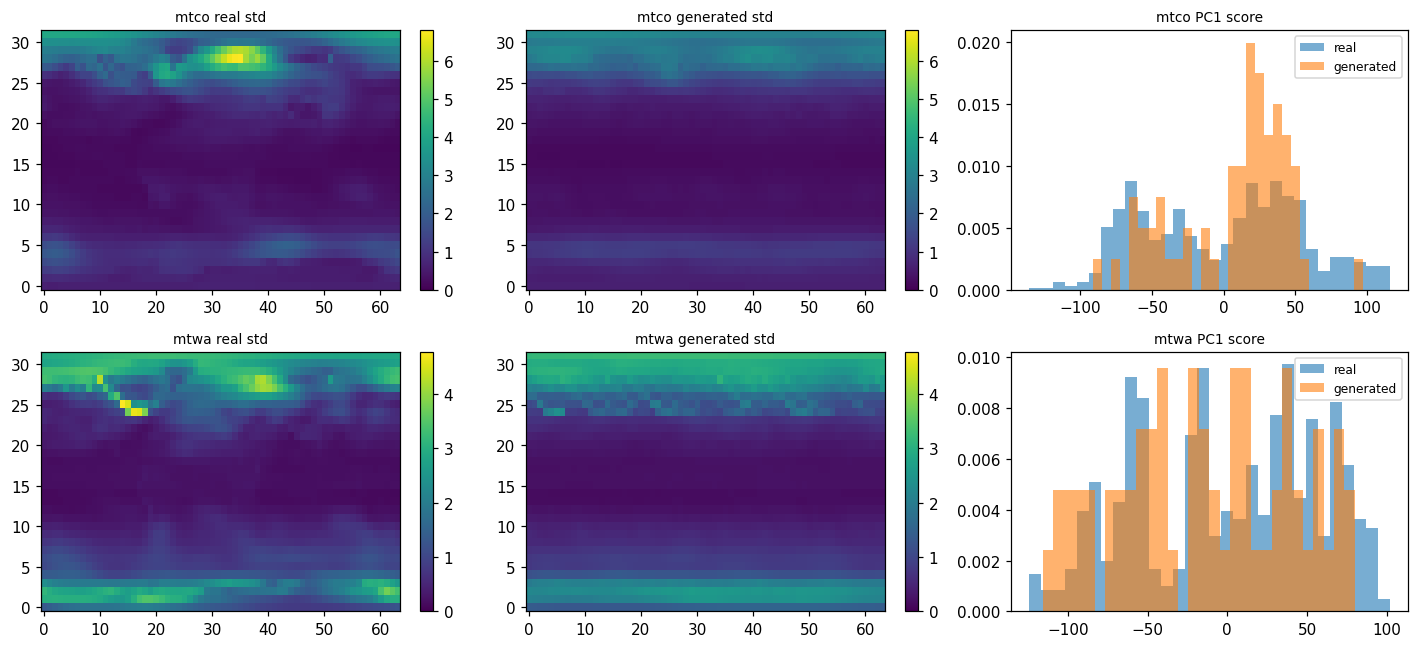

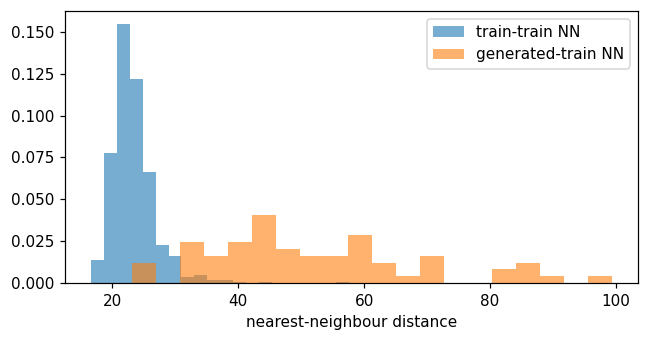

In [5]:
prior_samples = sampler_wh.sample_prior(64, seed=0)   # (64, 2, H, W) anomaly units
gen = prior_samples[:, :, safe_all]
real = anom_all[:, :, safe_all]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for c, name in enumerate(VARS):
    vmax = float(real[:, c].std(0).max())
    for col, (title, field) in enumerate((("real std", real[:, c].std(0)),
                                          ("generated std", gen[:, c].std(0)))):
        m = np.full(safe_all.shape, np.nan); m[safe_all] = field
        ax = axes[c, col]
        im = ax.imshow(m, origin="lower", cmap="viridis", vmin=0, vmax=vmax, aspect="auto")
        ax.set_title(f"{name} {title}", fontsize=9); fig.colorbar(im, ax=ax, fraction=0.046)
    # leading-PC score distribution, generated vs real
    Xr = real[:, c] - real[:, c].mean(0)
    u, s, vt = np.linalg.svd(Xr, full_matrices=False)
    pc = vt[0]
    axes[c, 2].hist((Xr @ pc), bins=30, density=True, alpha=0.6, label="real")
    axes[c, 2].hist(((gen[:, c] - real[:, c].mean(0)) @ pc), bins=30, density=True,
                    alpha=0.6, label="generated")
    axes[c, 2].set_title(f"{name} PC1 score", fontsize=9); axes[c, 2].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "unconditional_quality.png", bbox_inches="tight")

# memorisation: nearest training state for each generated sample vs a train-train baseline.
# cdist avoids the O(N^2 * D) broadcast that would materialise ~20 GB for ~800 states.
from scipy.spatial.distance import cdist

gv = gen.reshape(len(gen), -1)
rv = real.reshape(len(real), -1)
d_gen = cdist(gv, rv).min(1)
dd = cdist(rv, rv); np.fill_diagonal(dd, np.inf)
d_train = dd.min(1)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(d_train, bins=20, density=True, alpha=0.6, label="train-train NN")
ax.hist(d_gen, bins=20, density=True, alpha=0.6, label="generated-train NN")
ax.set_xlabel("nearest-neighbour distance"); ax.legend(); fig.tight_layout()
fig.savefig(FIG / "memorisation.png", bbox_inches="tight")
print("median NN distance  generated:", round(float(np.median(d_gen)), 3),
      " train:", round(float(np.median(d_train)), 3))

## Run the generative lanes

PPE on the older-half prior, withholding on the all-ages prior. `gamma` is swept on
the selection split and reported at its winner on the test split; withholding is
age-subsampled for cost (the stride is recorded in the config). Results share the
`outputs/da/generative/` schema, so notebook 09 compares them against 3DVar.

In [6]:
d = OUT / "generative"
if d.exists():
    shutil.rmtree(d)

gex.run_ppe_generative(
    cube, ages, lats, lons, valid, long_ppe, str(d), sampler=sampler_ppe,
    gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
    truth_stride=TRUTH_STRIDE, progress_every=5)

gex.run_withholding_generative(
    cube, ages, lats, lons, valid, long_wh, str(d), sampler=sampler_wh,
    gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
    fold_kind="random", age_stride=6, progress_every=1)
print("wrote", sorted(p.name for p in d.iterdir()))

  gamma 1/5 (20%, elapsed 124s, eta 497s)
  gamma 2/5 (40%, elapsed 230s, eta 345s)
  gamma 3/5 (60%, elapsed 337s, eta 225s)
  gamma 4/5 (80%, elapsed 446s, eta 112s)
  gamma 5/5 (100%, elapsed 561s, eta 0s)
  truth 5/41 (12%, elapsed 15s, eta 106s)
  truth 10/41 (24%, elapsed 26s, eta 82s)
  truth 15/41 (37%, elapsed 39s, eta 68s)
  truth 20/41 (49%, elapsed 52s, eta 54s)
  truth 25/41 (61%, elapsed 65s, eta 41s)
  truth 30/41 (73%, elapsed 77s, eta 28s)
  truth 35/41 (85%, elapsed 90s, eta 15s)
  truth 40/41 (98%, elapsed 103s, eta 3s)
  gamma (withholding_random) 1/5 (20%, elapsed 1374s, eta 5498s)
  gamma (withholding_random) 2/5 (40%, elapsed 2855s, eta 4282s)
  gamma (withholding_random) 3/5 (60%, elapsed 4215s, eta 2810s)
  gamma (withholding_random) 4/5 (80%, elapsed 5638s, eta 1409s)
  gamma (withholding_random) 5/5 (100%, elapsed 7035s, eta 0s)
  test-fold (withholding_random) 1/5 (20%, elapsed 267s, eta 1067s)
  test-fold (withholding_random) 2/5 (40%, elapsed 528s, eta 793

## Prior vs posterior

The gamma tuning curve (selection RRMSE), the prior-to-posterior variance reduction
(reused from the 3DVar diagnostic), and the pointwise prior/posterior distribution
at a cell near a site and one far from any site.

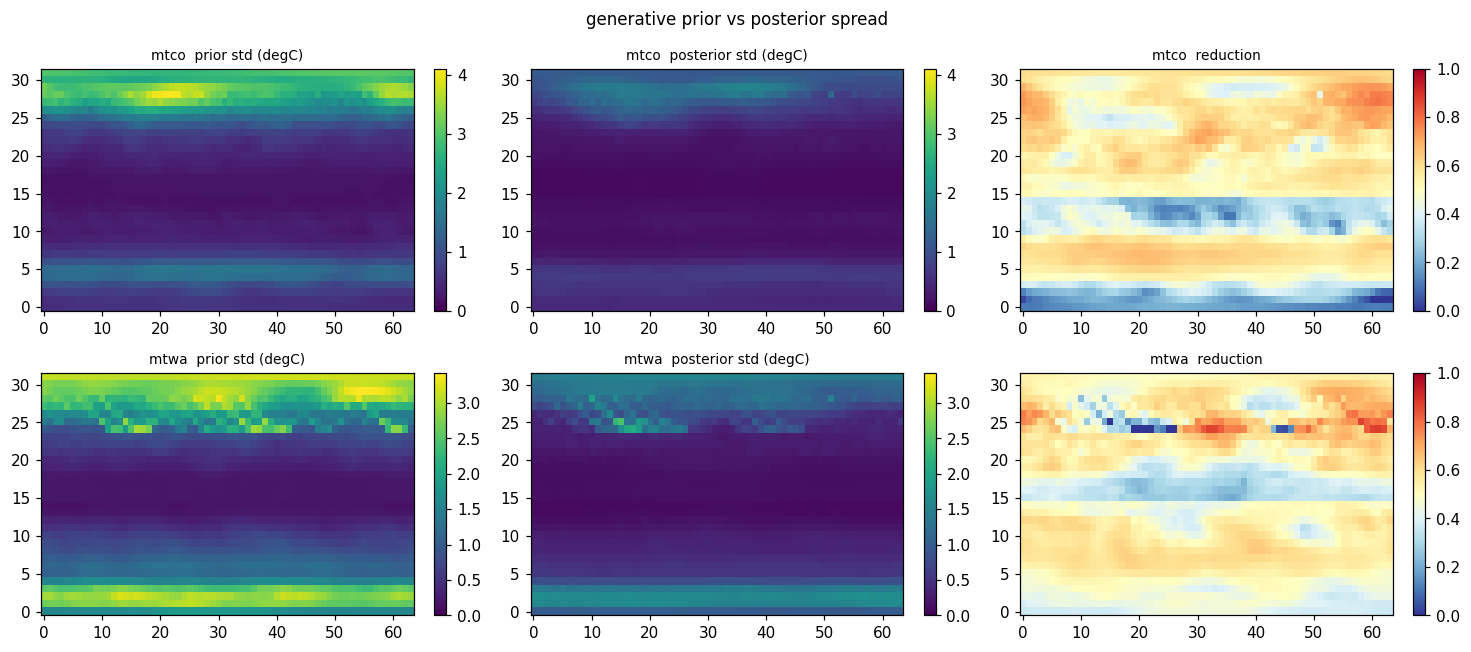

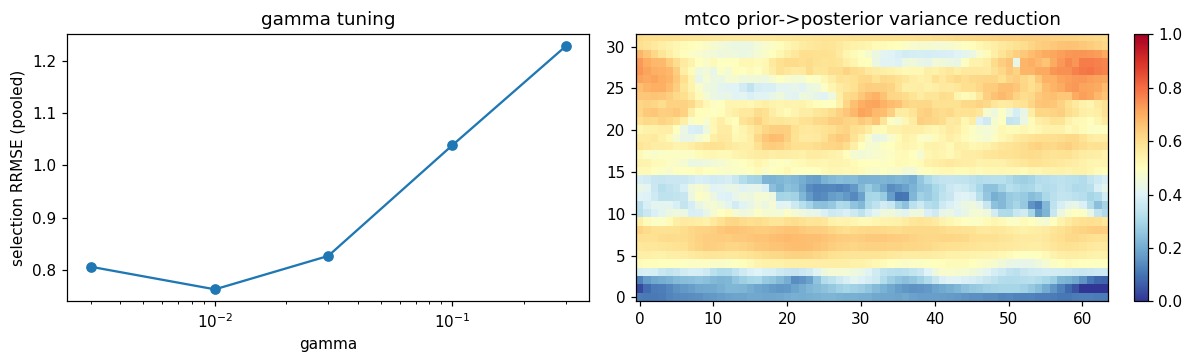

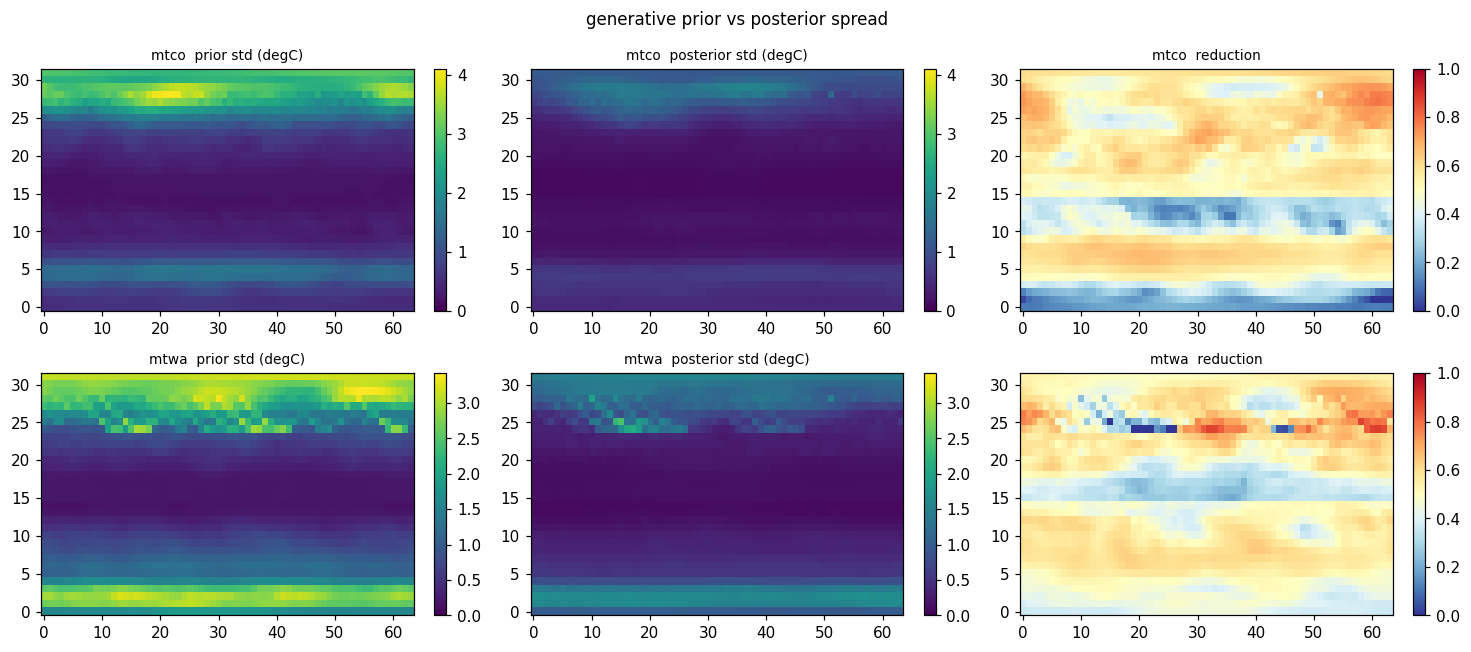

In [7]:
M = pd.read_csv(OUT / "generative" / "metrics.csv")
sel = M[(M.lane == "ppe") & (M.split == "selection") & (M.channel == "pooled")
        & (M.do_event == "all") & (M.metric == "rrmse")].sort_values("b_scale")

z = np.load(OUT / "generative" / "ppe_analysis.npz")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(sel["b_scale"], sel["value"], "o-"); ax[0].set_xscale("log")
ax[0].set_xlabel("gamma"); ax[0].set_ylabel("selection RRMSE (pooled)")
ax[0].set_title("gamma tuning")

red = da.uncertainty_reduction(z["prior_ens_var"], z["post_var"][0].mean(axis=0))
im = ax[1].imshow(np.where(safe_all, red[0], np.nan), origin="lower", cmap="RdYlBu_r",
                  vmin=0, vmax=1, aspect="auto")
ax[1].set_title("mtco prior->posterior variance reduction")
fig.colorbar(im, ax=ax[1], fraction=0.046)
fig.tight_layout(); fig.savefig(FIG / "gamma_and_variance_reduction.png", bbox_inches="tight")

da.plot_prior_posterior_uncertainty(
    z["prior_ens_var"], z["post_var"][0].mean(axis=0), safe_all, VARS,
    title="generative prior vs posterior spread",
    save_path=str(FIG / "uncertainty_reduction_generative.png"))

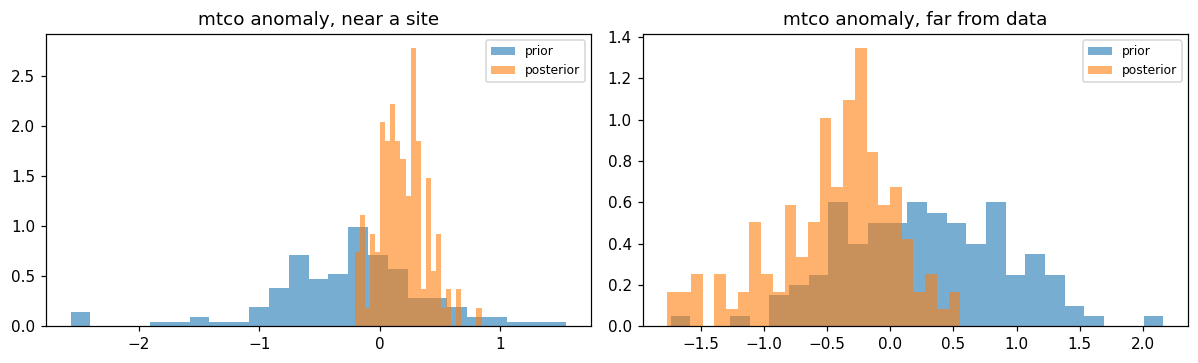

In [8]:
# Pointwise prior vs posterior at a near-site and a far cell (mtco), for one truth.
from paleoreco.assim.observations import observations_at_age
from paleoreco.assim.experiments import _obs_geometry

n_cells = len(lats) * len(lons)
safe_flat = np.broadcast_to(safe_a, (len(VARS), *safe_a.shape)).ravel()
age0 = int(z["drawn_ages"][0, -1])
geom = _obs_geometry(observations_at_age(long_ppe, age0), lats, lons, safe_flat)
truth0 = z["truth_anom"][0]
y0 = truth0.ravel()[geom["gather"]]
gamma_star = float(z["b_scales"][0])
post = sampler_ppe.sample_posterior(geom["gather"], y0, geom["sse"], gamma_star, 128, seed=1)
prior = sampler_ppe.sample_prior(128, seed=2)

# Index the mtco channel (cells 0..n_cells-1) at an observed site and at the void.
near = int(geom["gather"][0]) % n_cells
far = int(np.argmax(da.nearest_obs_distance(lats, lons, geom["lat"], geom["lon"])))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, (cell, label) in zip(ax, ((near, "near a site"), (far, "far from data"))):
    a.hist(prior.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6, label="prior")
    a.hist(post.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6, label="posterior")
    a.set_title(f"mtco anomaly, {label}"); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "pointwise_prior_posterior.png", bbox_inches="tight")

## Reading

The cross-method comparison against 3DVar (skill, calibration, prior-to-posterior,
gallery) lives in `09_da_comparison`, which discovers `outputs/da/generative/`
automatically. Bimodality-recovery near D-O transitions is the next milestone.